## First Question: What factor determines the survival?

1. Does the ticket class impact survival?
2. Is there a difference in survival rate between the genders
3. How does age impact survival rates?
4. Can we predict the survival of the passenger with high accuracy?

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [8]:
gender_data = pd.read_csv('/content/drive/MyDrive/datasets/gender_submission.csv')

In [9]:
test_data = pd.read_csv('/content/drive/MyDrive/datasets/test.csv')

In [10]:
titanic_data = pd.read_csv('/content/drive/MyDrive/datasets/train.csv')

In [11]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
#Check missing values
titanic_data.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [14]:
#Check duplicated values
titanic_data.duplicated().sum()

np.int64(0)

In [15]:
titanic_data['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [16]:
titanic_data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [17]:
titanic_df = titanic_data.copy()

In [18]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [19]:
# Data Cleaning
columns = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
titanic_df = titanic_df[columns]
titanic_df


,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [20]:
# Find the average statistics
titanic_df.describe()

,Survived,Pclass,Age,Fare
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208
std,0.486592,0.836071,14.526497,49.693429
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,7.910400
50%,0.000000,3.000000,28.000000,14.454200
75%,1.000000,3.000000,38.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


<Axes: xlabel='Pclass', ylabel='count'>

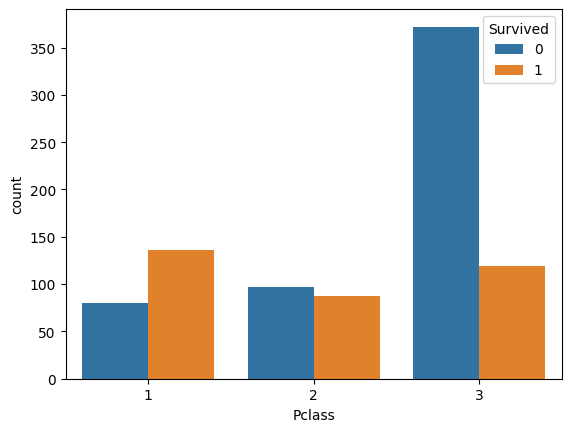

In [21]:

sns.countplot(x='Pclass', hue = 'Survived', data=titanic_df)

<Axes: ylabel='Age'>

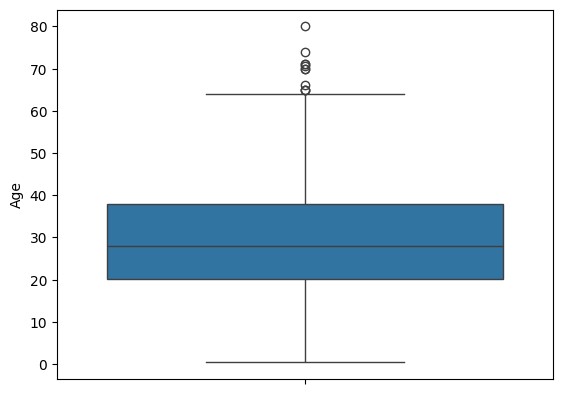

In [22]:
sns.boxplot(titanic_df['Age'])

<Axes: xlabel='Sex', ylabel='count'>

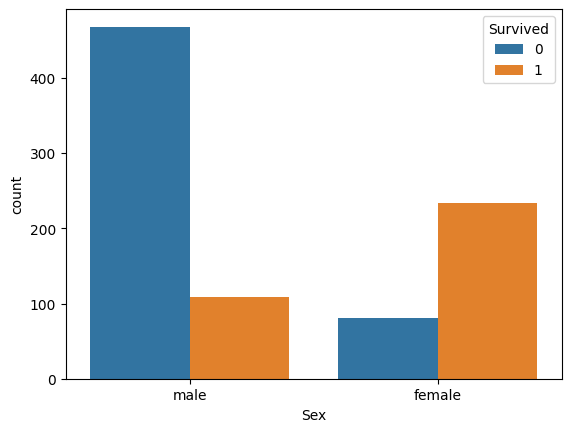

In [23]:
sns.countplot(x='Sex', hue = 'Survived', data=titanic_df)

In [24]:
titanic_data.groupby('Survived')['Age'].mean()

,Age
Survived,
0,30.626179
1,28.343690


<Axes: xlabel='Age', ylabel='Count'>

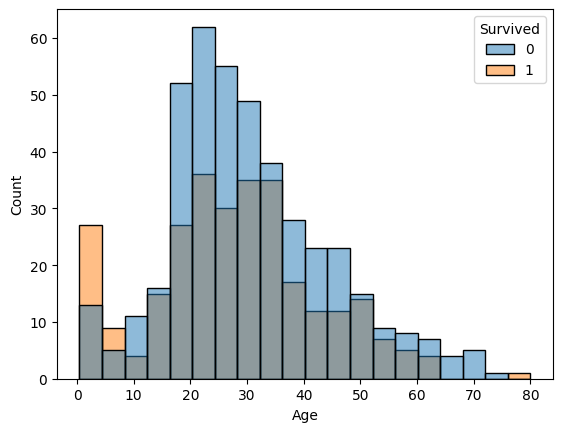

In [25]:
sns.histplot(x='Age', hue = 'Survived', data=titanic_df)

<Axes: xlabel='Age', ylabel='Count'>

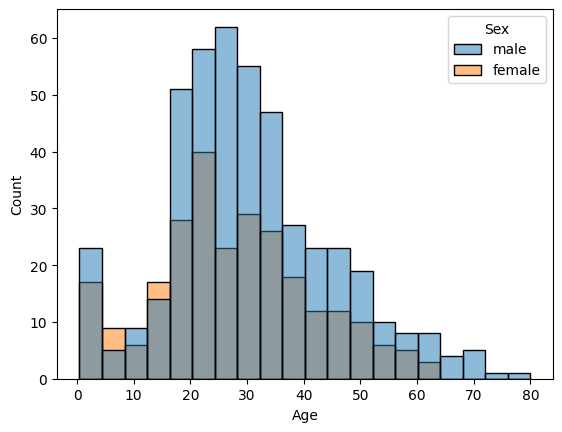

In [26]:
sns.histplot(x='Age', hue = 'Sex', data=titanic_df)

<Axes: ylabel='Fare'>

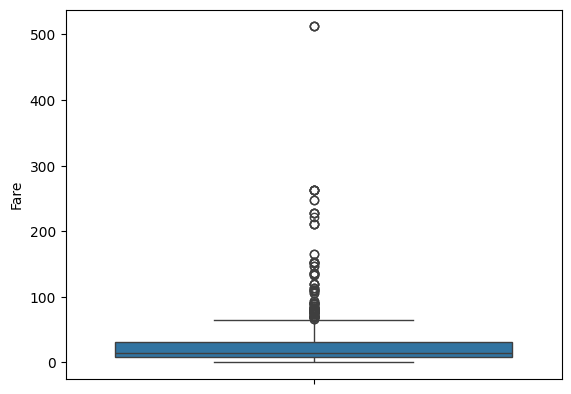

In [27]:
sns.boxplot(titanic_df['Fare'])

In [28]:
titanic_data.groupby('Survived')['Fare'].mean()

,Fare
Survived,
0,22.117887
1,48.395408


In [29]:
titanic_data.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


<Axes: xlabel='Fare', ylabel='Count'>

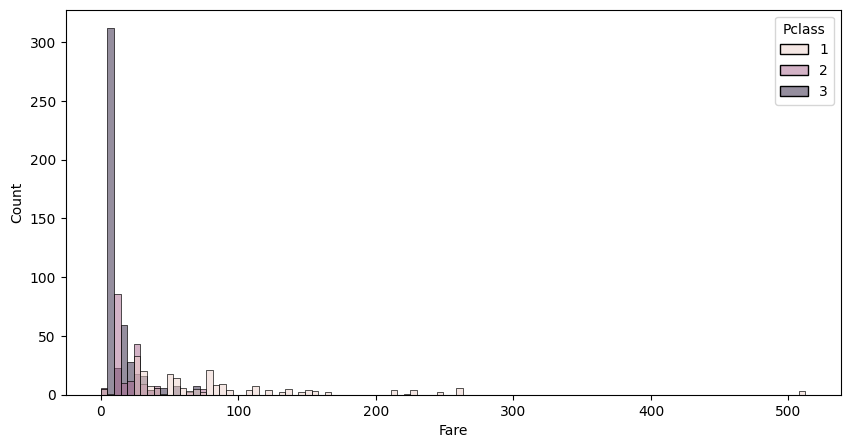

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(x='Fare', hue = 'Pclass', data=titanic_df)

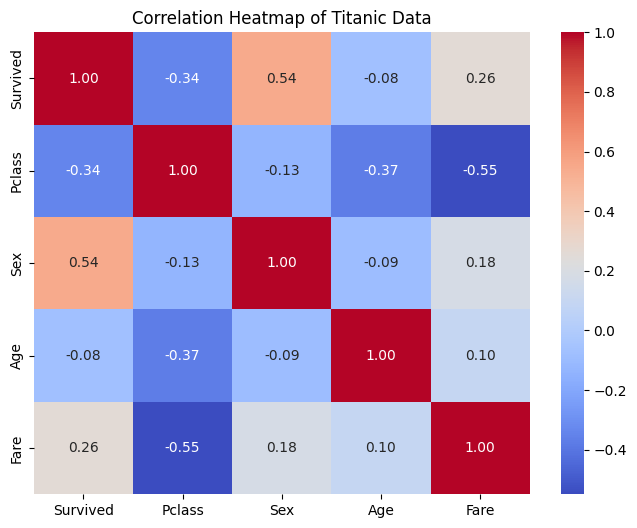

In [31]:
# Feature Engineering
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

correlation_matrix = titanic_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Titanic Data')
plt.show()

In [32]:
titanic_df['Sex'].head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [33]:
# Fill missing values with mean
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())

titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   Fare      891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [34]:
titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [35]:
titanic_df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,32.204208
std,0.486592,0.836071,0.477990,13.002015,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,29.699118,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


In [38]:
# x is Feature. It is the columns that we use to predict the answer
x = titanic_df.drop('Survived', axis=1) # pertanyaan

# y is known as target
y = titanic_df['Survived'] # kunci jawabannya this is what we want to predict

### Feature Scaling

In [39]:
# Scale the uneven data so the machine learning is more optimal
# e.g biar rentagnya gak terlalu jauh
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [40]:
x

array([[ 0.82737724, -0.73769513, -0.5924806 , -0.50244517],
       [-1.56610693,  1.35557354,  0.63878901,  0.78684529],
       [ 0.82737724,  1.35557354, -0.2846632 , -0.48885426],
       ...,
       [ 0.82737724,  1.35557354,  0.        , -0.17626324],
       [-1.56610693, -0.73769513, -0.2846632 , -0.04438104],
       [ 0.82737724, -0.73769513,  0.17706291, -0.49237783]])

In [41]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Model Training

In [42]:
# Logistic Regression
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [43]:
# Classification Report
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [57]:
rf = RandomForestClassifier()
scores = cross_val_score(rf, x, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.79329609 0.79775281 0.85955056 0.80337079 0.80898876]
Mean accuracy: 0.8125918021467579


In [56]:
# Display Feature importance
feature_names = titanic_df.drop('Survived', axis=1).columns
importances = pd.Series(rf.fit(x_train, y_train).feature_importances_, index=feature_names)
importances.sort_values(ascending=False)

,0
Fare,0.334421
Age,0.288690
Sex,0.281268
Pclass,0.095621


### Model Evaluation

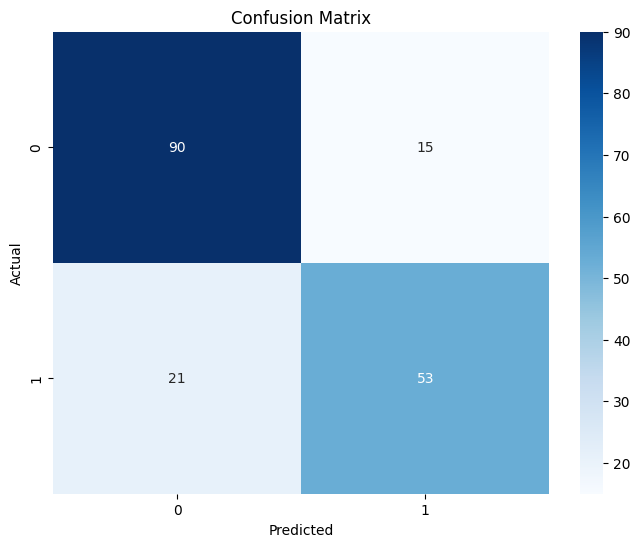

In [45]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()